# S7C-A: retarded-time bearing measurement validation

## tl;dr

One instantaneous bearing does not determine range. Four temporal bearings from one station retain rank 4 for radial motion, but the ideal finite-c retarded model is formally rank 6 for the specified nonradial motion. Its weakest singular value is only about 1.63e-8 and the SI-scaled condition number is about 2.67e6, so formal local rank is not robust practical ranging. The independently derived instantaneous limit has rank 5 and the expected scale null direction.

## Context & Methods

This diagnostic notebook validates a supplied constant-velocity 6-D state in a homogeneous stationary medium. It contains no state estimator, filter, process noise, estimated track, GCC/SRP signal fusion, or future-measurement access. Reception timestamps drive propagation; availability timestamps are causal metadata only.

### Key Assumptions

- velocity is strictly constant and subsonic; c and synchronized reception times are exact;
- local rank uses the standard max(shape)*machine-epsilon*s_max threshold, not a tuned cutoff;
- position and velocity columns stay in native SI units, so condition numbers depend on parameter scaling;
- the c→infinity model is derived independently at reception time and never passes infinity to the production solver.

In [1]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

from model.dynamic_state import ConstantVelocityState
from model.measurements import BearingMeasurement
from model.retarded_bearing import predict_retarded_bearing, stack_retarded_bearing_observability
from validation.retarded_bearing_validation import (
    run_retarded_bearing_validation,
    stacked_instantaneous_world_direction_jacobian,
    validation_stations,
)

metrics = run_retarded_bearing_validation(Path('../results/retarded_bearing_model_summary.csv'))
metrics

{'scene_count': 1000,
 'ordinary_speed_scene_count': 950,
 'near_sonic_scene_count': 50,
 'seed': 20260901,
 'max_emission_equation_residual_s': 1.1102230246251565e-15,
 'max_analytic_numeric_emission_time_difference_s': 4.884981308350689e-15,
 'max_emission_time_jacobian_abs_mismatch': 6.915884531721872e-12,
 'max_local_direction_jacobian_abs_mismatch': 4.486511717693986e-10,
 'max_tangent_residual_jacobian_abs_mismatch': 2.725225094202255e-09,
 'max_jacobian_relative_mismatch': 3.861468973416781e-06,
 'one_station_temporal_radial_rank': 4,
 'one_station_temporal_radial_smallest_singular_value': 1.5312424663145318e-18,
 'one_station_temporal_nonradial_rank': 6,
 'one_station_temporal_nonradial_smallest_singular_value': 1.6270620060085154e-08,
 'one_station_temporal_nonradial_condition_number': 2670001.46786563,
 'one_station_temporal_nonradial_fd_max_abs_mismatch': 5.663698676716677e-13,
 'one_station_temporal_nonradial_fd_spectral_norm_mismatch': 8.354790381042242e-13,
 'one_station_

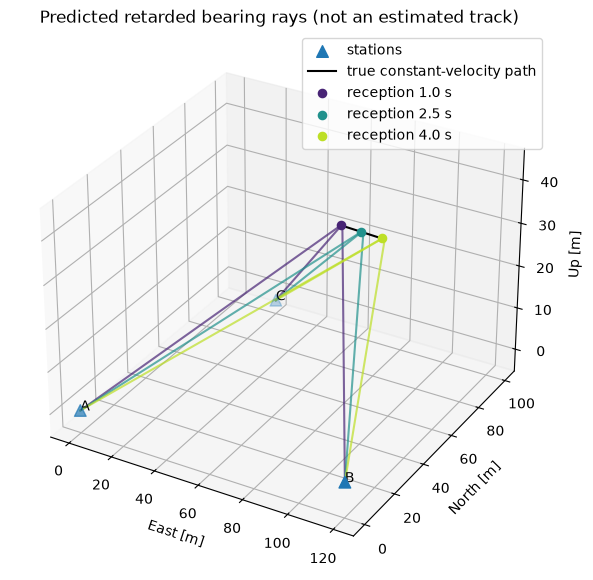

In [2]:
stations = validation_stations()
state = ConstantVelocityState([80.0, 50.0, 40.0], [8.0, -3.0, 1.0], 0.0)
reception_times = np.array([1.0, 2.5, 4.0])
predictions = [[predict_retarded_bearing(state, station, t) for station in stations] for t in reception_times]

fig = plt.figure(figsize=(9, 7))
ax = fig.add_subplot(111, projection='3d')
station_positions = np.array([station.position_world_m for station in stations])
ax.scatter(*station_positions.T, marker='^', s=70, label='stations')
for station in stations:
    ax.text(*station.position_world_m, station.station_id)
source_times = np.linspace(min(p.emission_time_s for row in predictions for p in row), max(p.emission_time_s for row in predictions for p in row), 100)
source_path = np.array([state.position_at(t) for t in source_times])
ax.plot(*source_path.T, color='black', label='true constant-velocity path')
colors = plt.cm.viridis(np.linspace(0.1, 0.9, len(reception_times)))
for color, t, row in zip(colors, reception_times, predictions):
    for station, prediction in zip(stations, row):
        endpoint = station.position_world_m + prediction.range_m * prediction.direction_world
        segment = np.vstack([station.position_world_m, endpoint])
        ax.plot(*segment.T, color=color, alpha=0.7)
    ax.scatter(*row[0].source_position_at_emission_world_m, color=color, s=35, label=f'reception {t:.1f} s')
ax.set(xlabel='East [m]', ylabel='North [m]', zlabel='Up [m]', title='Predicted retarded bearing rays (not an estimated track)')
ax.legend(loc='best')
plt.show()

In [3]:
timing_rows = []
measurements = []
for frame, (reception, row) in enumerate(zip(reception_times, predictions)):
    for station, prediction in zip(stations, row):
        timing_rows.append((station.station_id, reception, prediction.emission_time_s, prediction.propagation_delay_s, prediction.range_m))
        measurements.append(BearingMeasurement(station.station_id, 'notebook', frame, reception, reception + 0.02, prediction.direction_local, np.diag([1e-5, 2e-5]), np.zeros(2), 'direct'))
print('station  reception_s  emission_s  delay_s  range_m')
for row in timing_rows:
    print(f'{row[0]:>7s} {row[1]:12.6f} {row[2]:11.6f} {row[3]:8.6f} {row[4]:8.3f}')
diagnostic = stack_retarded_bearing_observability(state, stations, measurements)
print()
print(f'stacked shape={diagnostic.jacobian.shape}, rank={diagnostic.rank}, condition={diagnostic.condition_number:.6g}')

station  reception_s  emission_s  delay_s  range_m
      A     1.000000    0.690533 0.309467  106.147
      B     1.000000    0.797477 0.202523   69.465
      C     1.000000    0.725301 0.274699   94.222
      A     2.500000    2.165766 0.334234  114.642
      B     2.500000    2.318895 0.181105   62.119
      C     2.500000    2.191933 0.308067  105.667
      A     4.000000    3.638941 0.361059  123.843
      B     4.000000    3.834140 0.165860   56.890
      C     4.000000    3.657880 0.342120  117.347

stacked shape=(18, 6), rank=6, condition=9.5779


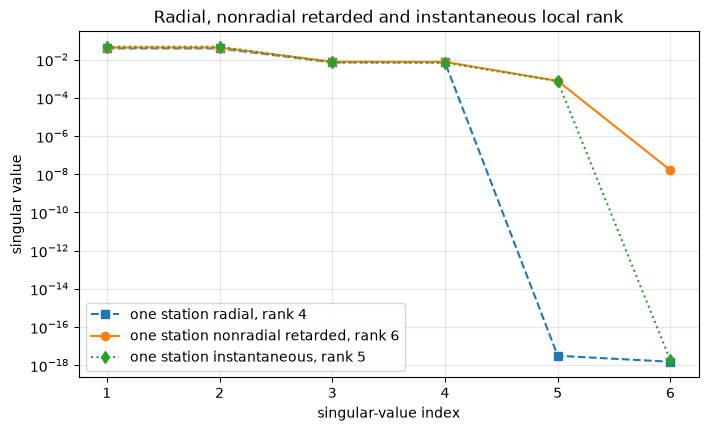

nonradial s_min: 1.6270620060085154e-08
nonradial SI-scaled condition: 2670001.46786563
finite-difference max mismatch: 5.663698676716677e-13
FD mismatch / s_min: 3.480935978961724e-05


In [4]:
one_station = stations[0]
one_station_times = np.array([1.0, 2.0, 3.0, 4.0])
radial_state = ConstantVelocityState([80.0, 50.0, 40.0], [8.0, 5.0, 4.0], 0.0)
nonradial_state = ConstantVelocityState([80.0, 50.0, 40.0], [8.0, -3.0, 1.0], 0.0)

def ideal_one_station_measurements(candidate_state, sequence_id):
    records = []
    for frame, reception in enumerate(one_station_times):
        prediction = predict_retarded_bearing(candidate_state, one_station, reception)
        records.append(BearingMeasurement(one_station.station_id, sequence_id, frame, reception, reception + 0.02, prediction.direction_local, np.diag([1e-5, 2e-5]), np.zeros(2), 'direct'))
    return records

radial = stack_retarded_bearing_observability(radial_state, [one_station], ideal_one_station_measurements(radial_state, 'radial'))
nonradial = stack_retarded_bearing_observability(nonradial_state, [one_station], ideal_one_station_measurements(nonradial_state, 'nonradial'))
instantaneous_jacobian = stacked_instantaneous_world_direction_jacobian(nonradial_state, one_station, one_station_times)
instantaneous_singular_values = np.linalg.svd(instantaneous_jacobian, compute_uv=False)
instantaneous_tolerance = max(instantaneous_jacobian.shape) * np.finfo(float).eps * instantaneous_singular_values[0]
instantaneous_rank = int(np.count_nonzero(instantaneous_singular_values > instantaneous_tolerance))

assert radial.rank == 4
assert nonradial.rank == 6
assert instantaneous_rank == 5
assert metrics['one_station_temporal_nonradial_fd_max_abs_mismatch'] < nonradial.singular_values[-1] * 1e-3

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.semilogy(np.arange(1, 7), radial.singular_values, 's--', label=f'one station radial, rank {radial.rank}')
ax.semilogy(np.arange(1, 7), nonradial.singular_values, 'o-', label=f'one station nonradial retarded, rank {nonradial.rank}')
ax.semilogy(np.arange(1, 7), instantaneous_singular_values, 'd:', label=f'one station instantaneous, rank {instantaneous_rank}')
ax.set(xlabel='singular-value index', ylabel='singular value', title='Radial, nonradial retarded and instantaneous local rank')
ax.grid(True, which='both', alpha=0.3)
ax.legend()
plt.show()
print('nonradial s_min:', nonradial.singular_values[-1])
print('nonradial SI-scaled condition:', nonradial.condition_number)
print('finite-difference max mismatch:', metrics['one_station_temporal_nonradial_fd_max_abs_mismatch'])
print('FD mismatch / s_min:', metrics['one_station_temporal_nonradial_fd_max_to_smin_ratio'])

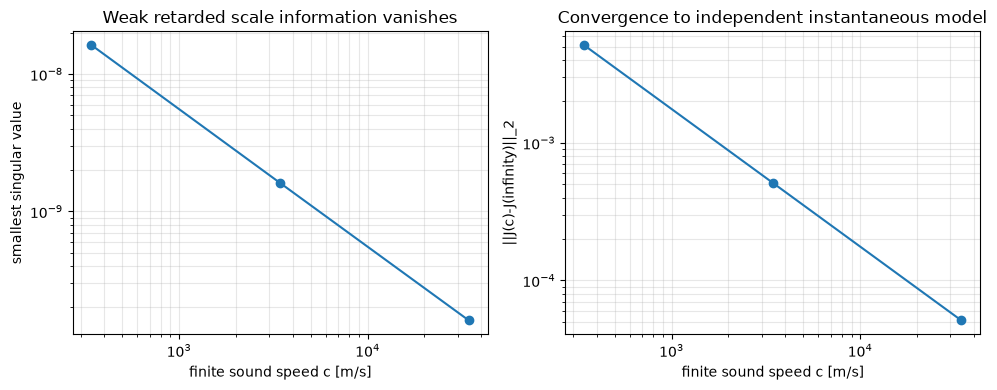

instantaneous rank: 5
instantaneous scale-null max abs residual: 1.0408340855860843e-16
finite-c ranks: [6, 6, 6]
The finite-c matrices remain structurally rank 6 while converging to the rank-5 limit.
This is a retarded-time measurement-model validation, not tracking.


In [5]:
sound_speeds = np.array([343.0, 3430.0, 34300.0])
smallest = np.array([metrics[f'one_station_nonradial_c_{int(c)}_smallest_singular_value'] for c in sound_speeds])
distance_to_limit = np.array([metrics[f'one_station_nonradial_c_{int(c)}_to_instantaneous_spectral_norm'] for c in sound_speeds])
scale_null_direction = np.concatenate((nonradial_state.position_at_reference_world_m - one_station.position_world_m, nonradial_state.velocity_world_mps))
null_residual = instantaneous_jacobian @ scale_null_direction
assert np.max(np.abs(null_residual)) < 2e-16
assert np.all(np.diff(smallest) < 0.0)
assert np.all(np.diff(distance_to_limit) < 0.0)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].loglog(sound_speeds, smallest, 'o-')
axes[0].set(xlabel='finite sound speed c [m/s]', ylabel='smallest singular value', title='Weak retarded scale information vanishes')
axes[1].loglog(sound_speeds, distance_to_limit, 'o-')
axes[1].set(xlabel='finite sound speed c [m/s]', ylabel='||J(c)-J(infinity)||_2', title='Convergence to independent instantaneous model')
for ax in axes:
    ax.grid(True, which='both', alpha=0.3)
plt.tight_layout()
plt.show()
print('instantaneous rank:', instantaneous_rank)
print('instantaneous scale-null max abs residual:', np.max(np.abs(null_residual)))
print('finite-c ranks:', [metrics[f'one_station_nonradial_c_{int(c)}_rank'] for c in sound_speeds])
print('The finite-c matrices remain structurally rank 6 while converging to the rank-5 limit.')
print('This is a retarded-time measurement-model validation, not tracking.')

## Takeaways

A single instantaneous bearing contains no range information. A radial constant-velocity temporal stack remains rank deficient. For the ideal finite-speed retarded-time model, the selected non-radial trajectory is formally rank 6, but its additional scale information is extremely weak and disappears as $c \rightarrow \infty$. The independent instantaneous Jacobian has rank 5 with the expected scale-null direction. These results support the multi-station architecture for robust 3D localization; they do not constitute tracking or a claim of practically usable single-station ranging.